In [249]:
import sys
print(sys.executable)

C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\.venv\Scripts\python.exe


In [250]:
import pandas as pd
from pathlib import Path
import numpy as np
from math import radians, sin, cos, sqrt, atan2
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Directorio actual (donde corre el notebook)
CURRENT_DIR = Path.cwd()
print("📂 Directorio actual:", CURRENT_DIR)

# 2) Buscar hacia arriba hasta encontrar /data/clean
BASE_DIR = None
for p in [CURRENT_DIR] + list(CURRENT_DIR.parents):
    if (p / "data" / "clean").exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "No encontré la carpeta 'data/clean' subiendo desde el directorio actual.\n"
        f"Directorio actual: {CURRENT_DIR}"
    )

CLEAN_DIR = BASE_DIR / "data" / "clean"
print("📁 Base del proyecto detectada:", BASE_DIR)
print("📁 Carpeta clean detectada:", CLEAN_DIR)

# 3) Lista de archivos que esperas
files = {
    "df_muni": "dim_municipio_final.csv",
    "df_ccaa": "dim_ccaa_base.csv",
    "df_prov": "dim_provincia_base.csv",
    "df_isla": "dim_isla.csv",
    "df_rel":  "rel_municipio_isla.csv",
    "df_geo":  "dim_geografia_municipio_osm.csv"
}

# 4) Verificación rápida de existencia
missing = [name for name in files.values() if not (CLEAN_DIR / name).exists()]
if missing:
    raise FileNotFoundError(
        "Faltan estos archivos en data/clean:\n- " + "\n- ".join(missing)
        + "\n\nArchivos encontrados en clean:\n"
        + "\n".join([f.name for f in CLEAN_DIR.glob("*")])
    )

# 5) Cargar (ya sin error)
df_muni = pd.read_csv(CLEAN_DIR / files["df_muni"], dtype=str, encoding="utf-8-sig")
df_ccaa = pd.read_csv(CLEAN_DIR / files["df_ccaa"], dtype=str, encoding="utf-8-sig")
df_prov = pd.read_csv(CLEAN_DIR / files["df_prov"], dtype=str, encoding="utf-8-sig")
df_isla = pd.read_csv(CLEAN_DIR / files["df_isla"], dtype=str, encoding="utf-8-sig")
df_rel  = pd.read_csv(CLEAN_DIR / files["df_rel"],  dtype=str, encoding="utf-8-sig")
df_geo  = pd.read_csv(CLEAN_DIR / files["df_geo"],  dtype=str, encoding="utf-8-sig")

print("\n✅ Archivos cargados correctamente:")
print("dim_municipio_final:", df_muni.shape)
print("dim_ccaa_base:", df_ccaa.shape)
print("dim_provincia_base:", df_prov.shape)
print("dim_isla:", df_isla.shape)
print("rel_municipio_isla:", df_rel.shape)
print("dim_geografia_municipio_osm:", df_geo.shape)

df_geo["lat"] = pd.to_numeric(df_geo["lat"], errors="coerce")
df_geo["lon"] = pd.to_numeric(df_geo["lon"], errors="coerce")

📂 Directorio actual: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\Notebook\New_Model
📁 Base del proyecto detectada: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM
📁 Carpeta clean detectada: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\data\clean

✅ Archivos cargados correctamente:
dim_municipio_final: (8132, 13)
dim_ccaa_base: (19, 4)
dim_provincia_base: (52, 4)
dim_isla: (11, 6)
rel_municipio_isla: (155, 7)
dim_geografia_municipio_osm: (8132, 7)


## Diccionario de variables (resumen)

In [251]:
df_muni.head()

,id_pais,id_municipio,id_municipio_parcial,id_provincia,id_ccaa,nombre,provincia_nombre,ccaa_nombre,id_isla,isla,gid_municipio,gid_provincia,gid_ccaa
0,ES,16010513,010513,01,16,Agurain/Salvatierra,araba/álava,País Vasco,NaN,NaN,ES-16010513,ES-01,ES-16
1,ES,16010014,010014,01,16,Alegría-Dulantzi,araba/álava,País Vasco,NaN,NaN,ES-16010014,ES-01,ES-16
2,ES,16010029,010029,01,16,Amurrio,araba/álava,País Vasco,NaN,NaN,ES-16010029,ES-01,ES-16
3,ES,16010493,010493,01,16,Añana,araba/álava,País Vasco,NaN,NaN,ES-16010493,ES-01,ES-16
4,ES,16010035,010035,01,16,Aramaio,araba/álava,País Vasco,NaN,NaN,ES-16010035,ES-01,ES-16


In [252]:
df_geo.head()

,id_municipio,lat,lon,osm_id,osm_type,osm_query_usada,osm_pass
0,16010513,42.849282,-2.389059,340918,relation,"Agurain/Salvatierra, araba/álava, País Vasco, ...",pass_1
1,16010014,42.841519,-2.512052,348226,relation,"Alegría-Dulantzi, araba/álava, País Vasco, España",pass_1
2,16010029,43.051003,-2.999785,400902178,node,"Amurrio, araba/álava, País Vasco, España",pass_1
3,16010493,42.802150,-2.986417,339906,relation,"Añana, araba/álava, País Vasco, España",pass_1
4,16010035,43.035206,-2.585761,348225,relation,"Aramaio, araba/álava, País Vasco, España",pass_1


In [253]:
df_ccaa.head()

,id_pais,id_ccaa,ccaa_nombre,gid_ccaa
0,ES,01,Andalucía,ES-01
1,ES,02,Aragón,ES-02
2,ES,03,"Asturias, Principado de",ES-03
3,ES,04,"Balears, Illes",ES-04
4,ES,05,Canarias,ES-05


In [254]:
df_prov.head()

,id_pais,id_provincia,provincia_nombre,gid_provincia
0,ES,01,araba/álava,ES-01
1,ES,02,albacete,ES-02
2,ES,03,alicante/alacant,ES-03
3,ES,04,almería,ES-04
4,ES,05,ávila,ES-05


In [255]:
df_rel.head()

,id_pais,id_municipio,id_municipio_parcial,id_isla,isla,gid_isla,gid_municipio
0,ES,04070244,070244,07071,Formentera,ES-07071,ES-04070244
1,ES,04070260,070260,07072,Ibiza,ES-07072,ES-04070260
2,ES,04070466,070466,07072,Ibiza,ES-07072,ES-04070466
3,ES,04070504,070504,07072,Ibiza,ES-07072,ES-04070504
4,ES,04070488,070488,07072,Ibiza,ES-07072,ES-04070488


In [256]:
df_isla.head()

,id_pais,id_isla,isla,id_provincia,provincia_header,gid_isla
0,ES,07071,Formentera,07,Illes Balears,ES-07071
1,ES,07072,Ibiza,07,Illes Balears,ES-07072
2,ES,07073,Mallorca,07,Illes Balears,ES-07073
3,ES,07074,Menorca,07,Illes Balears,ES-07074
4,ES,35351,Fuerteventura,35,Las Palmas,ES-35351


## Tipo de dato y nulos

In [257]:
# Información general
df_muni.info()

# Tabla estructurada tipo diccionario de datos
eda_structure = pd.DataFrame({
    "Column Name": df_muni.columns,
    "Data Type": df_muni.dtypes.values,
    "NULLs allowed": ["Y" if df_muni[c].isna().any() else "N" for c in df_muni.columns],
    "NULL %": [round(df_muni[c].isna().mean()*100, 2) for c in df_muni.columns]
})

eda_structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8132 entries, 0 to 8131
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id_pais               8132 non-null   object
 1   id_municipio          8132 non-null   object
 2   id_municipio_parcial  8132 non-null   object
 3   id_provincia          8132 non-null   object
 4   id_ccaa               8132 non-null   object
 5   nombre                8132 non-null   object
 6   provincia_nombre      8132 non-null   object
 7   ccaa_nombre           8132 non-null   object
 8   id_isla               155 non-null    object
 9   isla                  155 non-null    object
 10  gid_municipio         8132 non-null   object
 11  gid_provincia         8132 non-null   object
 12  gid_ccaa              8132 non-null   object
dtypes: object(13)
memory usage: 826.0+ KB


,Column Name,Data Type,NULLs allowed,NULL %
0,id_pais,object,N,0.00
1,id_municipio,object,N,0.00
2,id_municipio_parcial,object,N,0.00
3,id_provincia,object,N,0.00
4,id_ccaa,object,N,0.00
5,nombre,object,N,0.00
6,provincia_nombre,object,N,0.00
7,ccaa_nombre,object,N,0.00
8,id_isla,object,Y,98.09
9,isla,object,Y,98.09


In [258]:
# Información general
df_geo.info()

# Tabla estructurada tipo diccionario de datos
eda_structure = pd.DataFrame({
    "Column Name": df_geo.columns,
    "Data Type": df_geo.dtypes.values,
    "NULLs allowed": ["Y" if df_geo[c].isna().any() else "N" for c in df_geo.columns],
    "NULL %": [round(df_geo[c].isna().mean()*100, 2) for c in df_geo.columns]
})

eda_structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8132 entries, 0 to 8131
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_municipio     8132 non-null   object 
 1   lat              8132 non-null   float64
 2   lon              8132 non-null   float64
 3   osm_id           8132 non-null   object 
 4   osm_type         8132 non-null   object 
 5   osm_query_usada  8132 non-null   object 
 6   osm_pass         8132 non-null   object 
dtypes: float64(2), object(5)
memory usage: 444.8+ KB


,Column Name,Data Type,NULLs allowed,NULL %
0,id_municipio,object,N,0.0
1,lat,float64,N,0.0
2,lon,float64,N,0.0
3,osm_id,object,N,0.0
4,osm_type,object,N,0.0
5,osm_query_usada,object,N,0.0
6,osm_pass,object,N,0.0


In [259]:
# Información general
df_ccaa.info()

# Tabla estructurada tipo diccionario de datos
eda_structure = pd.DataFrame({
    "Column Name": df_ccaa.columns,
    "Data Type": df_ccaa.dtypes.values,
    "NULLs allowed": ["Y" if df_ccaa[c].isna().any() else "N" for c in df_ccaa.columns],
    "NULL %": [round(df_ccaa[c].isna().mean()*100, 2) for c in df_ccaa.columns]
})

eda_structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id_pais      19 non-null     object
 1   id_ccaa      19 non-null     object
 2   ccaa_nombre  19 non-null     object
 3   gid_ccaa     19 non-null     object
dtypes: object(4)
memory usage: 740.0+ bytes


,Column Name,Data Type,NULLs allowed,NULL %
0,id_pais,object,N,0.0
1,id_ccaa,object,N,0.0
2,ccaa_nombre,object,N,0.0
3,gid_ccaa,object,N,0.0


In [260]:
# Información general
df_prov.info()

# Tabla estructurada tipo diccionario de datos
eda_structure = pd.DataFrame({
    "Column Name": df_prov.columns,
    "Data Type": df_prov.dtypes.values,
    "NULLs allowed": ["Y" if df_prov[c].isna().any() else "N" for c in df_prov.columns],
    "NULL %": [round(df_prov[c].isna().mean()*100, 2) for c in df_prov.columns]
})

eda_structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id_pais           52 non-null     object
 1   id_provincia      52 non-null     object
 2   provincia_nombre  52 non-null     object
 3   gid_provincia     52 non-null     object
dtypes: object(4)
memory usage: 1.8+ KB


,Column Name,Data Type,NULLs allowed,NULL %
0,id_pais,object,N,0.0
1,id_provincia,object,N,0.0
2,provincia_nombre,object,N,0.0
3,gid_provincia,object,N,0.0


In [261]:
# Información general
df_rel.info()

# Tabla estructurada tipo diccionario de datos
eda_structure = pd.DataFrame({
    "Column Name": df_rel.columns,
    "Data Type": df_rel.dtypes.values,
    "NULLs allowed": ["Y" if df_rel[c].isna().any() else "N" for c in df_rel.columns],
    "NULL %": [round(df_rel[c].isna().mean()*100, 2) for c in df_rel.columns]
})

eda_structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id_pais               155 non-null    object
 1   id_municipio          155 non-null    object
 2   id_municipio_parcial  155 non-null    object
 3   id_isla               155 non-null    object
 4   isla                  155 non-null    object
 5   gid_isla              155 non-null    object
 6   gid_municipio         155 non-null    object
dtypes: object(7)
memory usage: 8.6+ KB


,Column Name,Data Type,NULLs allowed,NULL %
0,id_pais,object,N,0.0
1,id_municipio,object,N,0.0
2,id_municipio_parcial,object,N,0.0
3,id_isla,object,N,0.0
4,isla,object,N,0.0
5,gid_isla,object,N,0.0
6,gid_municipio,object,N,0.0


In [262]:
# Información general
df_isla.info()

# Tabla estructurada tipo diccionario de datos
eda_structure = pd.DataFrame({
    "Column Name": df_isla.columns,
    "Data Type": df_isla.dtypes.values,
    "NULLs allowed": ["Y" if df_isla[c].isna().any() else "N" for c in df_isla.columns],
    "NULL %": [round(df_isla[c].isna().mean()*100, 2) for c in df_isla.columns]
})

eda_structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id_pais           11 non-null     object
 1   id_isla           11 non-null     object
 2   isla              11 non-null     object
 3   id_provincia      11 non-null     object
 4   provincia_header  11 non-null     object
 5   gid_isla          11 non-null     object
dtypes: object(6)
memory usage: 660.0+ bytes


,Column Name,Data Type,NULLs allowed,NULL %
0,id_pais,object,N,0.0
1,id_isla,object,N,0.0
2,isla,object,N,0.0
3,id_provincia,object,N,0.0
4,provincia_header,object,N,0.0
5,gid_isla,object,N,0.0


In [263]:
def analizar_dataframe_para_postgres(df, nombre_df="dataset"):

    resultados = []

    for col in df.columns:
        serie = df[col]
        dtype = serie.dtype
        nulos = serie.isna().sum()

        info = {
            "dataset": nombre_df,
            "columna": col,
            "dtype_pandas": str(dtype),
            "nulos": nulos
        }

        # ----------------------------
        # VARIABLES TEXTO
        # ----------------------------
        if dtype == "object":
            max_len = serie.astype(str).str.len().max()
            info["tipo_detectado"] = "texto"
            info["max_longitud"] = max_len

        # ----------------------------
        # VARIABLES NUMÉRICAS ENTERAS
        # ----------------------------
        elif np.issubdtype(dtype, np.integer):
            info["tipo_detectado"] = "entero"
            info["min"] = serie.min()
            info["max"] = serie.max()

        # ----------------------------
        # VARIABLES DECIMALES
        # ----------------------------
        elif np.issubdtype(dtype, np.floating):
            info["tipo_detectado"] = "decimal"
            info["min"] = serie.min()
            info["max"] = serie.max()

            # calcular decimales reales
            decimales = (
                serie.dropna()
                .astype(str)
                .str.split(".")
                .str[1]
                .str.len()
                .max()
            )
            info["max_decimales_observados"] = decimales

        else:
            info["tipo_detectado"] = "otro"

        resultados.append(info)

    return pd.DataFrame(resultados)

In [264]:
resumen_muni = analizar_dataframe_para_postgres(df_muni, "municipios")
display(resumen_muni)

,dataset,columna,dtype_pandas,nulos,tipo_detectado,max_longitud
0,municipios,id_pais,object,0,texto,2
1,municipios,id_municipio,object,0,texto,8
2,municipios,id_municipio_parcial,object,0,texto,6
3,municipios,id_provincia,object,0,texto,2
4,municipios,id_ccaa,object,0,texto,2
5,municipios,nombre,object,0,texto,47
6,municipios,provincia_nombre,object,0,texto,22
7,municipios,ccaa_nombre,object,0,texto,27
8,municipios,id_isla,object,7977,texto,5
9,municipios,isla,object,7977,texto,13


100% categórico
100% dimensional
Sin métricas numéricas
id_pais CHAR(2)
id_municipio CHAR(8)
id_municipio_parcial CHAR(8)
id_provincia CHAR(2)
id_ccaa CHAR(2)
nombre VARCHAR(60)
provincia_nombre VARCHAR(30)
ccaa_nombre VARCHAR(40)
id_isla CHAR(5)
isla VARCHAR(30)
gid_municipio CHAR(20)
gid_provincia CHAR(8)
gid_provincia CHAR(8)


In [265]:
resumen_ccaa = analizar_dataframe_para_postgres(df_ccaa, "comunidad_autonomas")
display(resumen_ccaa)

,dataset,columna,dtype_pandas,nulos,tipo_detectado,max_longitud
0,comunidad_autonomas,id_pais,object,0,texto,2
1,comunidad_autonomas,id_ccaa,object,0,texto,2
2,comunidad_autonomas,ccaa_nombre,object,0,texto,27
3,comunidad_autonomas,gid_ccaa,object,0,texto,5


100% categórico
100% jerárquico
Sin métricas cuantitativas
id_pais:
Código ISO->CHAR(2)
Longitud = 2
No es numérico real
id_ccaa:
Código administrativo oficial->CHAR(2)
Longitud = 2
Puede tener cero inicial
gid_ccaa:
Identificador global (ej: ES-07)->VARCHAR(5)
Longitud = 5
ccaa_nombre:
Nombre textual->VARCHAR(40
Máx longitud detectada: 27

In [266]:
resumen_prov = analizar_dataframe_para_postgres(df_prov, "provincia")
display(resumen_prov)

,dataset,columna,dtype_pandas,nulos,tipo_detectado,max_longitud
0,provincia,id_pais,object,0,texto,2
1,provincia,id_provincia,object,0,texto,2
2,provincia,provincia_nombre,object,0,texto,22
3,provincia,gid_provincia,object,0,texto,5


id_pais
Código país ISO (2 caracteres).->CHAR(2)
id_provincia
Código administrativo de provincia (2 caracteres, con ceros a la izquierda).->CHAR(2)
gid_provincia
Identificador global (ej. ES-07) → longitud 5.->VARCHAR(5)
provincia_nombre
Nombre de la provincia. Máx detectado: 22.->VARCHAR(30)

In [267]:
resumen_isla = analizar_dataframe_para_postgres(df_isla, "isla")
display(resumen_isla)

,dataset,columna,dtype_pandas,nulos,tipo_detectado,max_longitud
0,isla,id_pais,object,0,texto,2
1,isla,id_isla,object,0,texto,5
2,isla,isla,object,0,texto,13
3,isla,id_provincia,object,0,texto,2
4,isla,provincia_header,object,0,texto,22
5,isla,gid_isla,object,0,texto,8


id_pais
Código país ISO.->CHAR(2)
id_isla
Código interno de isla (EJ: cpro + cisla → 2 + 3 = 5).->CHAR(5)
id_provincia
Código provincia (2).->CHAR(2)
gid_isla
Global id (ej. ES-07001). Longitud 8.->VARCHAR(5)
isla
Nombre de la isla (máx 13).->VARCHAR(20)
provincia_header
Texto que venía en el header del Excel (máx 22).->VARCHAR(30)

In [268]:
resumen_rel = analizar_dataframe_para_postgres(df_rel, "isla_rel")
display(resumen_rel)

,dataset,columna,dtype_pandas,nulos,tipo_detectado,max_longitud
0,isla_rel,id_pais,object,0,texto,2
1,isla_rel,id_municipio,object,0,texto,8
2,isla_rel,id_municipio_parcial,object,0,texto,6
3,isla_rel,id_isla,object,0,texto,5
4,isla_rel,isla,object,0,texto,13
5,isla_rel,gid_isla,object,0,texto,8
6,isla_rel,gid_municipio,object,0,texto,11


id_pais
Código país ISO.->CHAR(2)
id_municipio
Código municipio nacional (8 chars).->CHAR(8)
id_municipio_parcial
Útil para auditoría (prov+mun+dc sin CCAA), pero no es PK.->CHAR(6)
id_isla
Código interno de isla (EJ: cpro + cisla → 2 + 3 = 5).->CHAR(5)
gid_isla
Global id (ej. ES-07001). Longitud 8.->VARCHAR(5)
isla
Nombre de la isla (máx 13).->VARCHAR(20)
gid_municipio->VARCHAR(11)


In [269]:
resumen_geo = analizar_dataframe_para_postgres(df_geo, "geografia")
display(resumen_geo)

,dataset,columna,dtype_pandas,nulos,tipo_detectado,max_longitud,min,max,max_decimales_observados
0,geografia,id_municipio,object,0,texto,8.0,NaN,NaN,NaN
1,geografia,lat,float64,0,decimal,NaN,27.637752,43.740593,7.0
2,geografia,lon,float64,0,decimal,NaN,-18.010723,4.290457,7.0
3,geografia,osm_id,object,0,texto,11.0,NaN,NaN,NaN
4,geografia,osm_type,object,0,texto,8.0,NaN,NaN,NaN
5,geografia,osm_query_usada,object,0,texto,95.0,NaN,NaN,NaN
6,geografia,osm_pass,object,0,texto,6.0,NaN,NaN,NaN


id_municipio → CHAR(8)
osm_id → VARCHAR(11)
osm_type → VARCHAR(8)
osm_query_usada → VARCHAR(95) (yo pondría VARCHAR(120) por seguridad)
osm_pass → VARCHAR(100) (ej. “pass_1”, “pass_2”)
lat y lon máximos decimales observados son 7 y rangos válidos España.-> NUMERIC(10,7) en la tabla salen 0 nulos en lat/lon pero Si en algún momento hay nulos, es mejor deja NULL permitido

# EDA básico: tipos, nulos, duplicados (para cada tabla)

In [270]:
def resumen_basico(df, name):
    print(f"\n--- {name} ---")
    print("Filas, columnas:", df.shape)
    print("Nulos por columna:\n", df.isna().sum())
    print("Duplicados totales:", df.duplicated().sum())
    display(df.head(5))

resumen_basico(df_muni, "dim_municipio_final")
resumen_basico(df_ccaa, "dim_ccaa_base")
resumen_basico(df_prov, "dim_provincia_base")
resumen_basico(df_isla, "dim_isla")
resumen_basico(df_rel, "rel_municipio_isla")
resumen_basico(df_geo, "dim_geografia_municipio_osm")


--- dim_municipio_final ---
Filas, columnas: (8132, 13)
Nulos por columna:
 id_pais                    0
id_municipio               0
id_municipio_parcial       0
id_provincia               0
id_ccaa                    0
nombre                     0
provincia_nombre           0
ccaa_nombre                0
id_isla                 7977
isla                    7977
gid_municipio              0
gid_provincia              0
gid_ccaa                   0
dtype: int64
Duplicados totales: 0


,id_pais,id_municipio,id_municipio_parcial,id_provincia,id_ccaa,nombre,provincia_nombre,ccaa_nombre,id_isla,isla,gid_municipio,gid_provincia,gid_ccaa
0,ES,16010513,010513,01,16,Agurain/Salvatierra,araba/álava,País Vasco,NaN,NaN,ES-16010513,ES-01,ES-16
1,ES,16010014,010014,01,16,Alegría-Dulantzi,araba/álava,País Vasco,NaN,NaN,ES-16010014,ES-01,ES-16
2,ES,16010029,010029,01,16,Amurrio,araba/álava,País Vasco,NaN,NaN,ES-16010029,ES-01,ES-16
3,ES,16010493,010493,01,16,Añana,araba/álava,País Vasco,NaN,NaN,ES-16010493,ES-01,ES-16
4,ES,16010035,010035,01,16,Aramaio,araba/álava,País Vasco,NaN,NaN,ES-16010035,ES-01,ES-16



--- dim_ccaa_base ---
Filas, columnas: (19, 4)
Nulos por columna:
 id_pais        0
id_ccaa        0
ccaa_nombre    0
gid_ccaa       0
dtype: int64
Duplicados totales: 0


,id_pais,id_ccaa,ccaa_nombre,gid_ccaa
0,ES,01,Andalucía,ES-01
1,ES,02,Aragón,ES-02
2,ES,03,"Asturias, Principado de",ES-03
3,ES,04,"Balears, Illes",ES-04
4,ES,05,Canarias,ES-05



--- dim_provincia_base ---
Filas, columnas: (52, 4)
Nulos por columna:
 id_pais             0
id_provincia        0
provincia_nombre    0
gid_provincia       0
dtype: int64
Duplicados totales: 0


...

,id_pais,id_isla,isla,id_provincia,provincia_header,gid_isla
0,ES,07071,Formentera,07,Illes Balears,ES-07071
1,ES,07072,Ibiza,07,Illes Balears,ES-07072
2,ES,07073,Mallorca,07,Illes Balears,ES-07073
3,ES,07074,Menorca,07,Illes Balears,ES-07074
4,ES,35351,Fuerteventura,35,Las Palmas,ES-35351



--- rel_municipio_isla ---
Filas, columnas: (155, 7)
Nulos por columna:
 id_pais                 0
id_municipio            0
id_municipio_parcial    0
id_isla                 0
isla                    0
gid_isla                0
gid_municipio           0
dtype: int64
Duplicados totales: 0


,id_pais,id_municipio,id_municipio_parcial,id_isla,isla,gid_isla,gid_municipio
0,ES,04070244,070244,07071,Formentera,ES-07071,ES-04070244
1,ES,04070260,070260,07072,Ibiza,ES-07072,ES-04070260
2,ES,04070466,070466,07072,Ibiza,ES-07072,ES-04070466
3,ES,04070504,070504,07072,Ibiza,ES-07072,ES-04070504
4,ES,04070488,070488,07072,Ibiza,ES-07072,ES-04070488



--- dim_geografia_municipio_osm ---
Filas, columnas: (8132, 7)
Nulos por columna:
 id_municipio       0
lat                0
lon                0
osm_id             0
osm_type           0
osm_query_usada    0
osm_pass           0
dtype: int64
Duplicados totales: 0


,id_municipio,lat,lon,osm_id,osm_type,osm_query_usada,osm_pass
0,16010513,42.849282,-2.389059,340918,relation,"Agurain/Salvatierra, araba/álava, País Vasco, ...",pass_1
1,16010014,42.841519,-2.512052,348226,relation,"Alegría-Dulantzi, araba/álava, País Vasco, España",pass_1
2,16010029,43.051003,-2.999785,400902178,node,"Amurrio, araba/álava, País Vasco, España",pass_1
3,16010493,42.802150,-2.986417,339906,relation,"Añana, araba/álava, País Vasco, España",pass_1
4,16010035,43.035206,-2.585761,348225,relation,"Aramaio, araba/álava, País Vasco, España",pass_1


# Validación PK (sin nulos ni duplicados)

In [271]:
def validar_pk(df, pk_col, name):
    nulos = df[pk_col].isna().sum()
    vacios = (df[pk_col].astype(str).str.strip() == "").sum()
    dups = df[pk_col].duplicated().sum()
    total = df.shape[0]
    unicos = df[pk_col].nunique(dropna=True)

    print(f"\n✅ PK Check: {name}.{pk_col}")
    print("Total:", total)
    print("Nulos:", nulos)
    print("Vacíos:", vacios)
    print("Duplicados:", dups)
    print("Únicos:", unicos)

# PK esperadas:
validar_pk(df_muni, "id_municipio", "dim_municipio_final")
validar_pk(df_ccaa, "id_ccaa", "dim_ccaa_base")
validar_pk(df_prov, "id_provincia", "dim_provincia_base")
validar_pk(df_isla, "id_isla", "dim_isla")


✅ PK Check: dim_municipio_final.id_municipio
Total: 8132
Nulos: 0
Vacíos: 0
Duplicados: 0
Únicos: 8132

✅ PK Check: dim_ccaa_base.id_ccaa
Total: 19
Nulos: 0
Vacíos: 0
Duplicados: 0
Únicos: 19

✅ PK Check: dim_provincia_base.id_provincia
Total: 52
Nulos: 0
Vacíos: 0
Duplicados: 0
Únicos: 52

✅ PK Check: dim_isla.id_isla
Total: 11
Nulos: 0
Vacíos: 0
Duplicados: 0
Únicos: 11


# Análisis específico “division_regional” (conteos y cobertura)

In [272]:
# Por CCAA (desde municipios)
if "id_ccaa" in df_muni.columns:
    conteo_ccaa = df_muni["id_ccaa"].value_counts().reset_index()
    conteo_ccaa.columns = ["id_ccaa", "num_municipios"]
    display(conteo_ccaa.head(20))

# Por provincia
if "id_provincia" in df_muni.columns:
    conteo_prov = df_muni["id_provincia"].value_counts().reset_index()
    conteo_prov.columns = ["id_provincia", "num_municipios"]
    display(conteo_prov.head(20))

,id_ccaa,num_municipios
0,07,2248
1,09,947
2,08,919
3,01,785
4,02,731
5,10,542
6,11,388
7,12,313
8,15,272
9,16,252


,id_provincia,num_municipios
0,09,371
1,37,362
2,08,311
3,50,293
4,19,288
5,31,272
6,46,266
7,49,248
8,05,248
9,16,238


In [273]:
# Cobertura de coordenadas por provincia / ccaa
# merge mini: municipio + geo para ver cobertura
mini = df_muni[["id_municipio","id_provincia","id_ccaa"]].merge(
    df_geo[["id_municipio","lat","lon"]],
    on="id_municipio",
    how="left"
)

mini["tiene_geo"] = mini["lat"].notna() & mini["lon"].notna()

cob_prov = mini.groupby("id_provincia")["tiene_geo"].mean().reset_index()
cob_prov["cobertura_pct"] = (cob_prov["tiene_geo"]*100).round(2)
display(cob_prov.sort_values("cobertura_pct").head(15))

cob_ccaa = mini.groupby("id_ccaa")["tiene_geo"].mean().reset_index()
cob_ccaa["cobertura_pct"] = (cob_ccaa["tiene_geo"]*100).round(2)
display(cob_ccaa.sort_values("cobertura_pct").head(10))

,id_provincia,tiene_geo,cobertura_pct
0,01,1.0,100.0
1,02,1.0,100.0
2,03,1.0,100.0
3,04,1.0,100.0
4,05,1.0,100.0
5,06,1.0,100.0
6,07,1.0,100.0
7,08,1.0,100.0
8,09,1.0,100.0
9,10,1.0,100.0


,id_ccaa,tiene_geo,cobertura_pct
0,01,1.0,100.0
1,02,1.0,100.0
2,03,1.0,100.0
3,04,1.0,100.0
4,05,1.0,100.0
5,06,1.0,100.0
6,07,1.0,100.0
7,08,1.0,100.0
8,09,1.0,100.0
9,10,1.0,100.0


In [274]:
# Validación puntual: Ceuta y Melilla
# Si provincia_nombre existe
if "provincia_nombre" in df_muni.columns:
    display(df_muni[df_muni["provincia_nombre"].isin(["ceuta","melilla"])].head(20))

# Ver si tienen geo
ceuta_melilla_ids = df_muni[df_muni.get("provincia_nombre","").isin(["ceuta","melilla"])][["id_municipio","provincia_nombre"]]
ceuta_geo = ceuta_melilla_ids.merge(df_geo[["id_municipio","lat","lon"]], on="id_municipio", how="left")
display(ceuta_geo)

,id_pais,id_municipio,id_municipio_parcial,id_provincia,id_ccaa,nombre,provincia_nombre,ccaa_nombre,id_isla,isla,gid_municipio,gid_provincia,gid_ccaa
8130,ES,18510013,510013,51,18,Ceuta,ceuta,Ceuta,NaN,NaN,ES-18510013,ES-51,ES-18
8131,ES,19520018,520018,52,19,Melilla,melilla,Melilla,NaN,NaN,ES-19520018,ES-52,ES-19


,id_municipio,provincia_nombre,lat,lon
0,18510013,ceuta,35.894422,-5.355817
1,19520018,melilla,35.291903,-2.940715


In [275]:
coord_por_municipio = (
    df_geo
    .groupby("id_municipio")[["lat", "lon"]]
    .nunique()
    .reset_index()
)
# Municipios con más de una lat o lng distinta
coord_incosistencias = coord_por_municipio[
    (coord_por_municipio["lat"]>1) | (coord_por_municipio["lon"]>1)
]
coord_incosistencias

print("Municipios con coordenadas inconsistentes:", coord_incosistencias.shape[0])

Municipios con coordenadas inconsistentes: 0


El análisis de integridad del dataset confirma que cada fila corresponde a un municipio único, sin presencia de registos duplicado o nulos. En total, el conjunto de datos contiene 8.132 municipios, coincidiendo el número de filas con el número de identificadores únicos, lo que garantiza una consistencia estructural del dataset.adicionalmente se puede confirmar que el dataset cuenta con coordenadas geográficas únicas asociadas. Lo cual asegura coherencia y permite el cálculo fiable de distancias geográficas mediante métricas como la fórmula de Haversine

# ¿Cuántas provincias comunidades autónomas y ciuadades están representadas?

In [276]:
num_provincias = df_prov["id_provincia"].nunique()
num_ccaa = df_ccaa["id_ccaa"].nunique()
num_isla = df_isla["id_isla"].nunique()
num_muni = df_muni["id_municipio"].nunique()
print(f"Número de provincias: {num_provincias}")
print(f"Número de comunidades autónomas: {num_ccaa}")
print(f"Número de islas: {num_isla}")
print(f"Número de municipios: {num_muni}")

Número de provincias: 52
Número de comunidades autónomas: 19
Número de islas: 11
Número de municipios: 8132


El dataset geográfico final contiene información correspondiente a 52 provincias, 19 comunidades autónomas, 8.132 municipios y 11 islas, lo que confirma una cobertura territorial completa del ámbito español.
Este resultado valida la idoneidad del conjunto de datos como base geográfica para el desarrollo del proyecto, garantizando la representatividad administrativa y territorial necesaria para el análisis espacial y la generación de recomendaciones turísticas a escala nacional.

# ¿Cómo se distribuyen los municipios entre las distintas comunidades autónomas de España?

In [277]:
df_join = df_muni.merge(df_geo, on="id_municipio", how="left")

In [278]:
df_join.head()

,id_pais,id_municipio,id_municipio_parcial,id_provincia,id_ccaa,nombre,provincia_nombre,ccaa_nombre,id_isla,isla,gid_municipio,gid_provincia,gid_ccaa,lat,lon,osm_id,osm_type,osm_query_usada,osm_pass
0,ES,16010513,010513,01,16,Agurain/Salvatierra,araba/álava,País Vasco,NaN,NaN,ES-16010513,ES-01,ES-16,42.849282,-2.389059,340918,relation,"Agurain/Salvatierra, araba/álava, País Vasco, ...",pass_1
1,ES,16010014,010014,01,16,Alegría-Dulantzi,araba/álava,País Vasco,NaN,NaN,ES-16010014,ES-01,ES-16,42.841519,-2.512052,348226,relation,"Alegría-Dulantzi, araba/álava, País Vasco, España",pass_1
2,ES,16010029,010029,01,16,Amurrio,araba/álava,País Vasco,NaN,NaN,ES-16010029,ES-01,ES-16,43.051003,-2.999785,400902178,node,"Amurrio, araba/álava, País Vasco, España",pass_1
3,ES,16010493,010493,01,16,Añana,araba/álava,País Vasco,NaN,NaN,ES-16010493,ES-01,ES-16,42.802150,-2.986417,339906,relation,"Añana, araba/álava, País Vasco, España",pass_1
4,ES,16010035,010035,01,16,Aramaio,araba/álava,País Vasco,NaN,NaN,ES-16010035,ES-01,ES-16,43.035206,-2.585761,348225,relation,"Aramaio, araba/álava, País Vasco, España",pass_1


In [279]:
ccaa_counts = (
    df_join
    .groupby("ccaa_nombre", as_index=False)
    .size()
    .rename(columns={"size": "total_municipios"})
    .sort_values("total_municipios", ascending=False)
)

In [280]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

<Figure size 1200x700 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

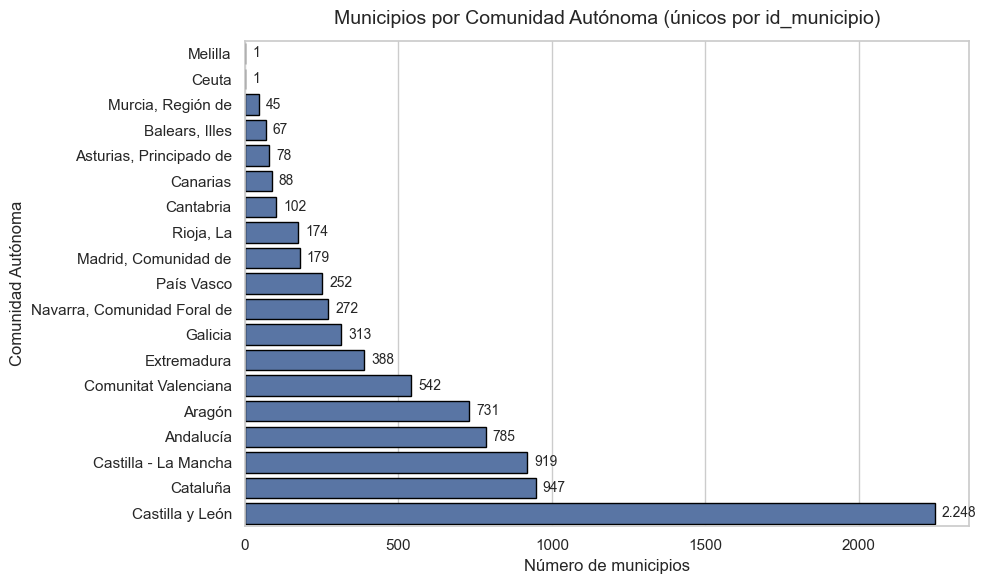

In [281]:

order = ccaa_counts.sort_values("total_municipios", ascending=True)["ccaa_nombre"].tolist()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=ccaa_counts,
    y="ccaa_nombre",
    x="total_municipios",
    order=order,
    edgecolor="black"
)

ax.set_title("Municipios por Comunidad Autónoma (únicos por id_municipio)", fontsize=14, pad=12)
ax.set_xlabel("Número de municipios", fontsize=12)
ax.set_ylabel("Comunidad Autónoma", fontsize=12)

for p in ax.patches:
    valor = int(p.get_width())
    ax.annotate(
        f"{valor:,}".replace(",", "."),
        (p.get_width(), p.get_y() + p.get_height()/2),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("municipios_por_ccaa.png", dpi=150)
plt.show()

Este análisis proporciona una base objetiva para adaptar el sistema de recomendación turística a la estructura territorial de cada comunidad autónoma, permitiendo ajustar el nilvel de granulidad de las recomendacion y optimizar la planificación de rutas culturales en función de la complejidad administrativa del territorio.

# Revisión de la estructura insulas de España

In [282]:
df_unicos = df_join.drop_duplicates(subset=["isla"])
# Conteo por CCAA (ordenado desc)
ccaa_counts = (
    df_unicos
    .groupby("ccaa_nombre", as_index=False)
    .size()
    .rename(columns={"size": "total_islas"})
    .sort_values("total_islas", ascending=False)
)

In [283]:
# ---------------------------
# 3) Gráfico de barras
# ---------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

<Figure size 1200x700 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

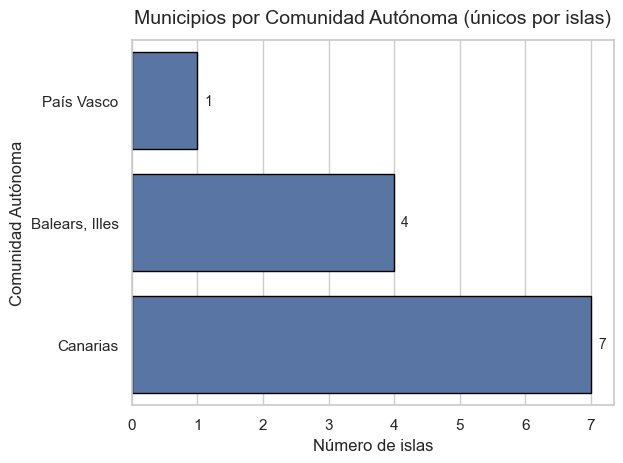

In [284]:
# Ordenar categorías por el conteo
order = ccaa_counts["ccaa_nombre"].tolist()[::-1]  # para barra horizontal ascendente visual
ax = sns.barplot(
    data=ccaa_counts,
    y="ccaa_nombre",
    x="total_islas",
    order=order,
    color="#4C72B0",
    edgecolor="black"
)

# Etiquetas y título
ax.set_title("Municipios por Comunidad Autónoma (únicos por islas)", fontsize=14, pad=12)
ax.set_xlabel("Número de islas", fontsize=12)
ax.set_ylabel("Comunidad Autónoma", fontsize=12)

# Anotar valores al final de cada barra
for p in ax.patches:
    valor = int(p.get_width())
    ax.annotate(f"{valor:,}".replace(",", "."),
                (p.get_x() + p.get_width(), p.get_y() + p.get_height()/2),
                xytext=(5, 0), textcoords="offset points",
                va="center", ha="left", fontsize=10)

plt.tight_layout()

# Guardar y mostrar
plt.savefig("islas_por_ccaa.png", dpi=150)
plt.show()

El siguiente análisis permite al sistema de recomendación turística adaptar la planificación de itinerarios, evitando la generación de rutas inviables por vía terreste y considerando la singularidad lógistica de los archipiélagos

# ¿Existen coordenadas geográficas atípicas o erróneas?

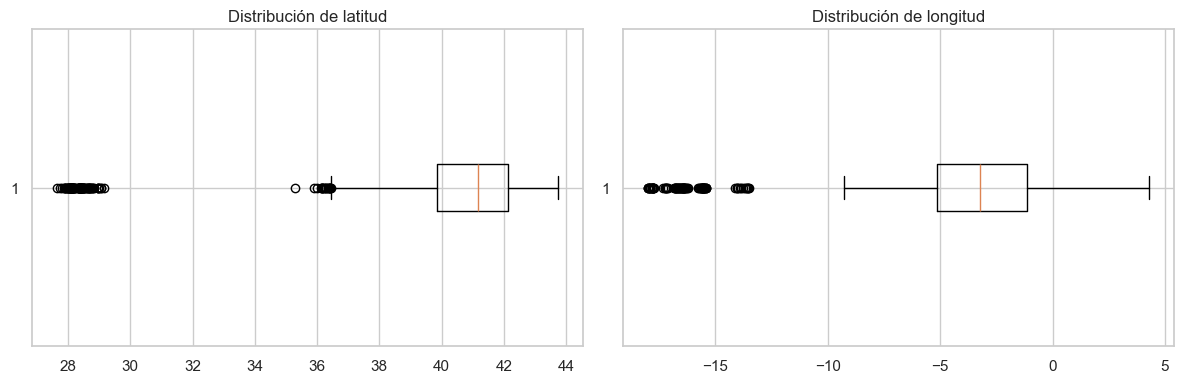

In [285]:
# Análisis de rangos válidos para España (latitudes y longitudes).
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df_geo["lat"], vert=False)
axes[0].set_title("Distribución de latitud")

axes[1].boxplot(df_geo["lon"], vert=False)
axes[1].set_title("Distribución de longitud")

plt.tight_layout()
plt.show()

### Analisis de Latitud
La mayoría de municipios se concentran aproximadamente entre 39° y 42° N
→ corresponde a la Península Ibérica
Aparece un grupo claro de valores más bajos, alrededor de 27–29° N
→ Islas Canarias
### Analisis Longitud
La mayor concentración está entre -6 y 2 grados
→ Península + Baleares
Se detecta un grupo de valores claramente más negativos (-18 a -13)
→ Canarias
No aparecen longitudes fuera del ámbito español

In [303]:
fuera_espana = df_join[
    ~(
        # Península
        ((df_join["lat"].between(36, 44)) &
         (df_join["lon"].between(-9, 3))) |

        # Baleares
        ((df_join["lat"].between(38, 40)) &
         (df_geo["lon"].between(1, 4))) |

        # Canarias
        ((df_join["lat"].between(27, 29)) &
         (df_join["lon"].between(-18, -13))) |

        # Ceuta
        ((df_join["lat"].between(35.8, 36.1)) &
         (df_join["lon"].between(-5.5, -5.1))) |

        # Melilla
        ((df_join["lat"].between(35.2, 35.5)) &
         (df_join["lon"].between(-3.1, -2.8)))
    )
]

In [304]:
fuera_espana = fuera_espana.copy()

# ¿Qué CCAA aparecen en los fuera de rango?
fuera_espana["ccaa_nombre"].value_counts().head(20)
fuera_espana[["ccaa_nombre","provincia_nombre","lat","lon"]].head(30)

,ccaa_nombre,provincia_nombre,lat,lon
795,"Balears, Illes",illes balears,39.933708,4.139767
810,"Balears, Illes",illes balears,39.879862,4.290457
811,"Balears, Illes",illes balears,40.000440,3.835237
820,"Balears, Illes",illes balears,39.983348,4.010947
830,"Balears, Illes",illes balears,39.889492,4.266207
833,"Balears, Illes",illes balears,39.988127,4.092600
834,"Balears, Illes",illes balears,39.945201,4.049234
843,"Balears, Illes",illes balears,40.037078,4.123466
849,"Balears, Illes",illes balears,39.849129,4.257983
2141,Galicia,a coruña,43.131058,-9.182559


In [301]:
fuera_espana = df_join[
    ~(
        # Península (incluye Galicia occidental)
        ((df_join["lat"].between(35.5, 44.5)) &
         (df_join["lon"].between(-9.5, 4.5))) |

        # Baleares (incluye Mallorca y Menorca)
        ((df_join["lat"].between(38.5, 40.3)) &
         (df_join["lon"].between(1.0, 4.5))) |

        # Canarias
        ((df_join["lat"].between(27.0, 29.6)) &
         (df_join["lon"].between(-18.5, -13.0))) |

        # Ceuta
        ((df_join["lon"].between(35.8, 36.1)) &
         (df_join["lon"].between(-5.5, -5.1))) |

        # Melilla
        ((df_join["lat"].between(35.2, 35.5)) &
         (df_join["lon"].between(-3.1, -2.8)))
    )
]

print("Municipios fuera de rangos esperados:", fuera_espana.shape[0])

Municipios fuera de rangos esperados: 0


El análisis de rango mediante boxplot confirma que las coordenadas geográficas del dataset se encuentran de los límites esperados dentro del territorio español. Los valores extremos identificados corresponden a territorios insulares, como Canarias y no a errores de Geocodificación, lo que valida la coherencia espacial del conjunto de datos.

La detección inicial de municipios fuera de los rangos definidos se debio a una delimitación geográfica excesivamente restrictiva. Tras ajustar los rango para incorporar zonas costeras y territorios extremos como Galicia occidential y las islas Baleares, se confirma que el 100% de los municipios presentan coordenadas coherentes con su ubicación real en el territorio español

# ¿Cuál es la distribución espacial de los municipios en el territorio español?

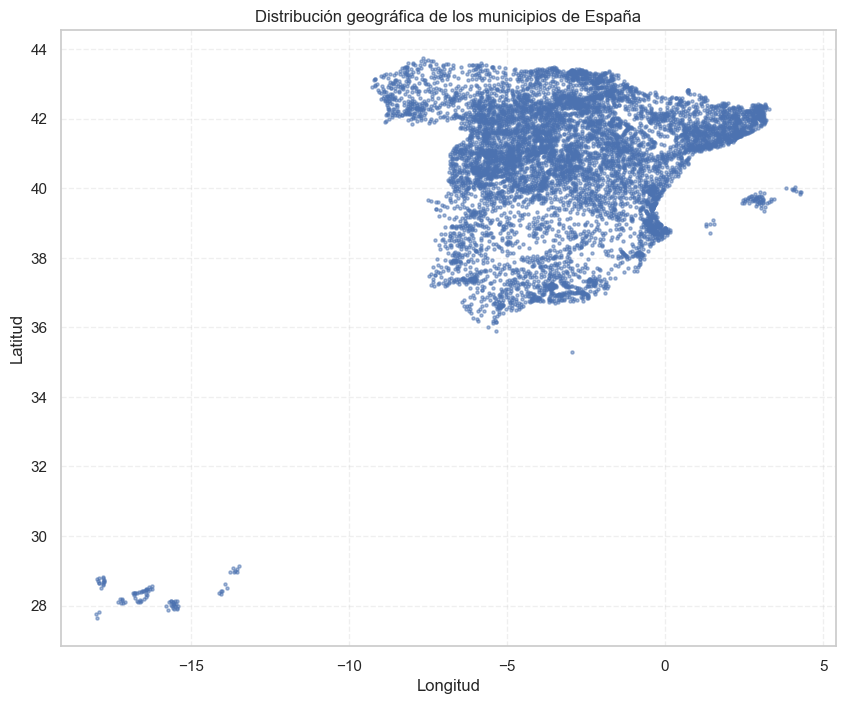

In [300]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df_join["lon"],
    df_join["lat"],
    s=5,
    alpha=0.5
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Distribución geográfica de los municipios de España")

plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

#### El diagrama de dispersión muestra:
La Península Ibérica claramente definida en el centro del gráfico
Las Islas Baleares separadas al este
Las Islas Canarias claramente aisladas al suroeste
No hay puntos fuera del territorio español

Esta validación visual demuestra la idoneidad del dataset como base geográfica para el cálculo de distancias, la planificación de rutas culturales y el diseño de un sistema de recomendación turística en proximidad geográfica

# ¿Cuál es la distancia media entre municipios dentro de una misma provincia?

In [288]:
#Paso 1 preparar datos númericos
df = df_join.copy()
df["lat"] = df["lat"].astype(float)
df["lng"] = df["lon"].astype(float)

In [289]:
# Paso 2 Calcular punto promedio central
centroides = (
    df.groupby("provincia_nombre")[["lat","lon"]]
    .mean()
    .rename(columns={"lat":"lat_c","lon":"lon_c"})
)

In [290]:
# Paso 3 Crear el calculo Haversine el cual es una fórmula utilizada para calcular la distancia entre dos puntos de una esfera dadas sus coordenadas de longitud y latitud.
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km radio de la tierra
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2  #-> calculan el ángulo central entre dos puntos sobre la superficie de una esfera
    c = 2 * atan2(sqrt(a), sqrt(1 - a)) #-> es el ángulo central entre los dos puntos, expresado en radianes.
    return R * c

In [291]:
# Paso 4 Distancia de cada municipio a su centroide
df = df.merge(centroides, on="provincia_nombre")

df["dist_centroide_km"] = df.apply(
    lambda x: haversine(x["lat"], x["lon"], x["lat_c"], x["lon_c"]),
    axis=1
)
"dist_centroide_km" in df.columns

True

In [292]:
#Dispersión media por provincia
dispersion = (
    df.groupby("provincia_nombre")["dist_centroide_km"]
    .mean()
    .sort_values(ascending=False)
)

El cálculo de distancias Haversine se realizó a nivel provincial, tomando como referencia el centroide geodráfico de cada provincia y midiendo la distancia media de los municipios a dicho punto. Este enfoque permitió analizar tanto el valor promedio como la dispersión territorial, identificando provincias compactas y altamente dispersias, información clave para el diseño de itinerarios turísticos eficientes.
Se calcula un centroide provincial (punto medio matemático)
Se mide qué tan lejos están, en promedio, los municipios de ese punto.

# ¿Cómo varía la accesibilidad territorial entre regiones?

In [293]:
distancia_media_ccaa = (
    df.groupby("ccaa_nombre")["dist_centroide_km"]
      .mean()
      .sort_values(ascending=False)
)
distancia_media_ccaa

ccaa_nombre
Canarias                       72.988655
Extremadura                    53.864371
Aragón                         48.091500
Castilla - La Mancha           47.554450
Asturias, Principado de        47.344560
Balears, Illes                 43.776304
Andalucía                      40.407873
Castilla y León                39.346001
Comunitat Valenciana           37.770561
Navarra, Comunidad Foral de    37.611008
Madrid, Comunidad de           36.914619
Cataluña                       35.760271
Galicia                        34.892279
Murcia, Región de              31.528525
Cantabria                      29.742692
Rioja, La                      26.978409
País Vasco                     18.771959
Ceuta                           0.000000
Melilla                         0.000000
Name: dist_centroide_km, dtype: float64

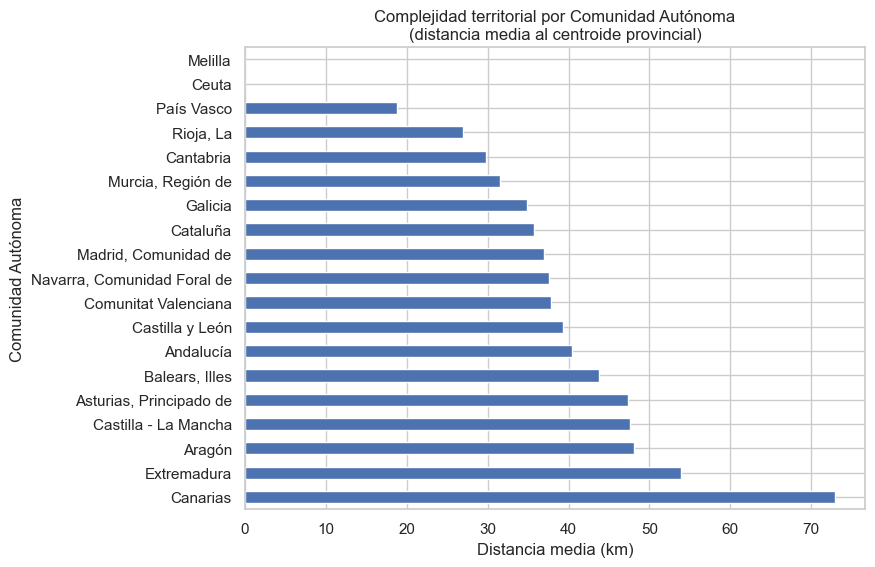

In [294]:
import matplotlib.pyplot as plt

distancia_media_ccaa.plot(
    kind="barh",
    figsize=(8,6),
    title="Complejidad territorial por Comunidad Autónoma\n(distancia media al centroide provincial)",
)

plt.xlabel("Distancia media (km)")
plt.ylabel("Comunidad Autónoma")
plt.show()

Las comunidades autónomas con mayores valores de distancia media al centroide presentan una mayor dispersión geográfica de sus municipios, lo que implica una mayor complejidad territorial. Este patrón es especialmente relevante para el diseño de itinerarios turísticos, ya que regiones más dispersas requieren rutas más largas y una planificación espacial más cuidadosa, mientras que regiones más compactas permiten recomendaciones más concentradas.

## Gráfico: provincias más y menos dispersas

### Top 10 provincias más dispersas

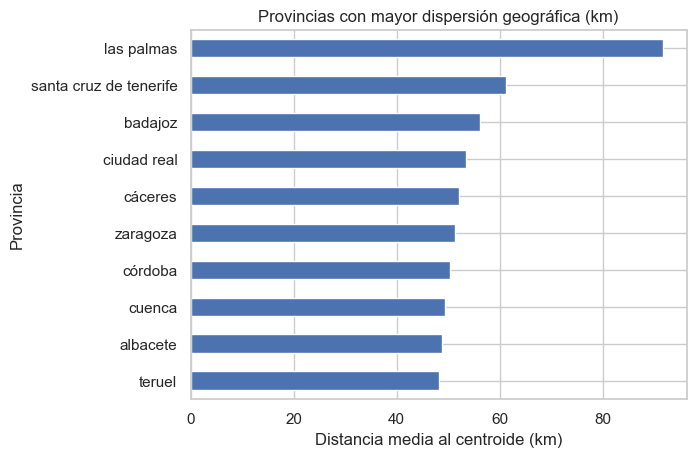

In [295]:
dispersion.head(10).plot(
    kind="barh",
    title="Provincias con mayor dispersión geográfica (km)",
    xlabel="Distancia media al centroide (km)",
    ylabel="Provincia",
)
plt.gca().invert_yaxis()
plt.show()

El gráfico identifica las provincias con mayor dispersión geográfica, entendida como una mayor distancia media de sus municipios respecto al cetroide provincial. Estas provincias presentan una estructura más extendida, por lo tanto desde la prespectiva del sistema de recomendación, estas provincias requiren estrategias de planificación más selectivas, priorizando rutas optimizadas y limitando el número de desplazamientos.

### Top 10 provincias mas cercanas

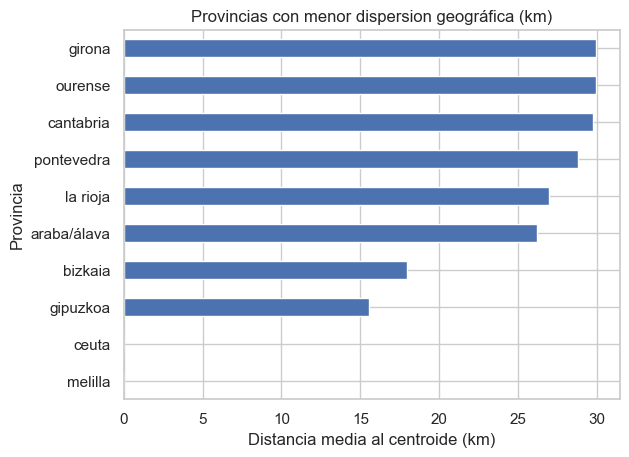

In [296]:
dispersion.tail(10).plot(
    kind="barh",
    title="Provincias con menor dispersion geográfica (km)",
    xlabel = "Distancia media al centroide (km)",
    ylabel = "Provincia"
)
plt.gca().invert_yaxis()
plt.show()

Las provicias con menor dispersión geográfica presentan una menor distancia media de sus municipios respecto al centroide provincial, lo que indica una mayor concentración territorial. por lo tanto permite al sistema de recomendación a planificar intenerarios culturales con múltiples paradas cercanas, al reducir los desplazamientos necesarios entre destinos.

In [297]:
municipios_centrales = (
    df.loc[df.groupby("provincia_nombre")["dist_centroide_km"].idxmin()]
    [["provincia_nombre", "nombre", "dist_centroide_km"]]
    .sort_values("dist_centroide_km")
)
municipios_centrales.head(10)

,provincia_nombre,nombre,dist_centroide_km
8130,ceuta,Ceuta,0.000000
8131,melilla,Melilla,0.000000
3168,gipuzkoa,Bidania-Goiatz,0.422524
5223,palencia,Villalcázar de Sirga,0.589776
3901,lleida,Foradada,0.601763
6492,tarragona,Riudecols,0.992151
2468,girona,Banyoles,1.023615
4623,navarra,Adiós,1.460342
7728,zamora,Perilla de Castro,1.519295
7545,bizkaia,Lezama,1.534229


In [298]:
df = df_join.copy()

# normalizar
df["id_provincia"] = df["id_provincia"].astype(str).str.zfill(2)
df["id_isla_norm"] = df["id_isla"].astype(str).str.strip().str.lower()

df["zona"] = "Península"

mask_isla = df["id_isla"].notna() & (df["id_isla_norm"] != "") & (df["id_isla_norm"] != "nan")

df.loc[mask_isla & (df["id_provincia"] == "07"), "zona"] = "Baleares"
df.loc[mask_isla & (df["id_provincia"].isin(["35", "38"])), "zona"] = "Canarias"

df["zona"].value_counts()

zona
Península    7977
Canarias       88
Baleares       67
Name: count, dtype: int64

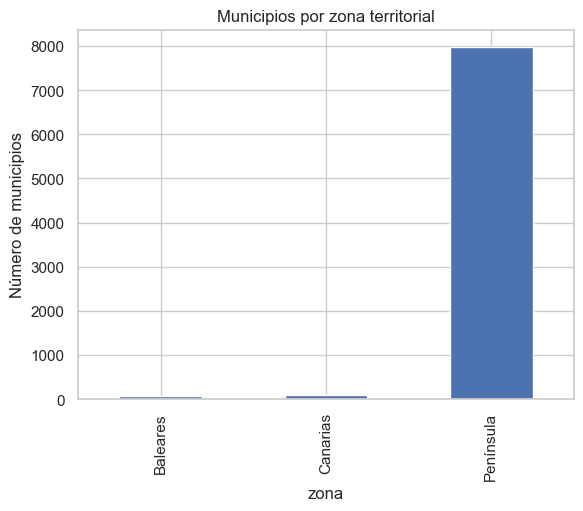

In [299]:
conteo_zona = df.groupby("zona")["id_municipio"].nunique()

conteo_zona.plot(kind="bar", title="Municipios por zona territorial")
plt.ylabel("Número de municipios")
plt.show()

El análisis del número de municipios por zona territorial pone de manifiesto una fuerta asimetría en la estructura administrativa española. La Penpinsula concentra la práctica totalidad de los municipios, reflejando una elevada fragmentación territorial y una continuidad geográfica que facilita el diseño de itinerarios terrestres extensos.
En contraste, Baleares y Canarias presentan un número significante menor de municipios y una distribución insular, lo que introduce restricciones logísticas relevantes para la planificación de rutas. Estas estadísticas justifican la necesidad de adaptar el sistema de recomendación turística a la realidad territorial de cada zona, incorporando segmentación por isla en los territorios insulares y evitando enfoques homogéneos a nivel nacional